In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

In [2]:
# MULTIPLE LINEAR REGRESSION -> multiple independent variables

In [3]:
df = pd.read_csv("50_Startups.csv")
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
lb = LabelEncoder()
df['State'] = lb.fit_transform(df['State'])
print(df)

    R&D Spend  Administration  Marketing Spend  State     Profit
0   165349.20       136897.80        471784.10      2  192261.83
1   162597.70       151377.59        443898.53      0  191792.06
2   153441.51       101145.55        407934.54      1  191050.39
3   144372.41       118671.85        383199.62      2  182901.99
4   142107.34        91391.77        366168.42      1  166187.94
5   131876.90        99814.71        362861.36      2  156991.12
6   134615.46       147198.87        127716.82      0  156122.51
7   130298.13       145530.06        323876.68      1  155752.60
8   120542.52       148718.95        311613.29      2  152211.77
9   123334.88       108679.17        304981.62      0  149759.96
10  101913.08       110594.11        229160.95      1  146121.95
11  100671.96        91790.61        249744.55      0  144259.40
12   93863.75       127320.38        249839.44      1  141585.52
13   91992.39       135495.07        252664.93      0  134307.35
14  119943.24       15654

In [5]:
X = df.drop('Profit',axis=1)  # or df(:,-1) as df(rows,columns), -1 indicates not picking last column
y = df['Profit']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [7]:
model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [8]:
r2 = r2_score(y_test,y_pred)
print(f"R2 Score: {r2:.4f}")
print("Intercept: ",model.intercept_)
print("Coeffients: ",model.coef_)

R2 Score: 0.9001
Intercept:  54080.716846113835
Coeffients:  [  0.80379465  -0.06791023   0.03126059 -16.82030683]


    Actual Profit  Predicted Profit
13      134307.35     126720.661507
39       81005.76      84909.089619
30       99937.59      98890.318549
45       64926.08      46479.312402
17      125370.37     129113.183188


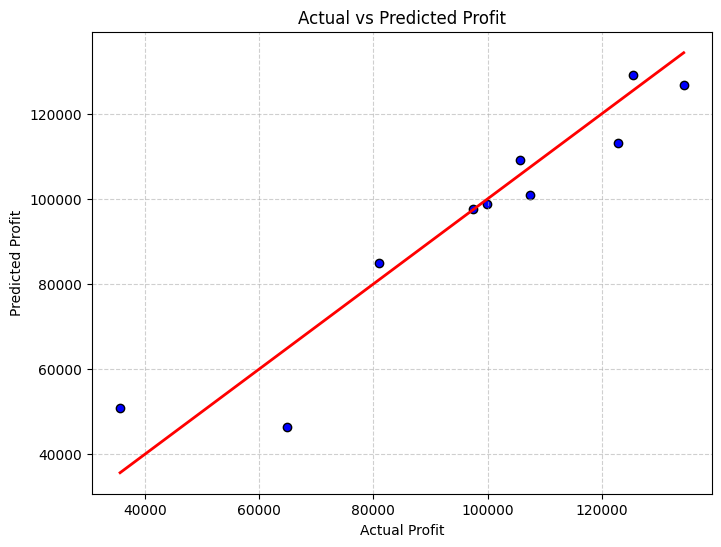

In [9]:
comparison = pd.DataFrame({'Actual Profit':y_test,"Predicted Profit":y_pred})
print(comparison.head())

plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,color='blue',edgecolor='black')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color='red',linewidth=2)
plt.title('Actual vs Predicted Profit')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

In [10]:
insur = pd.read_csv('insurance.csv')
insur

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...,...
1333,1333,50,male,30.970,3,no,northwest,10600.54830
1334,1334,18,female,31.920,0,no,northeast,2205.98080
1335,1335,18,female,36.850,0,no,southeast,1629.83350
1336,1336,21,female,25.800,0,no,southwest,2007.94500


Q. by aplying MLR, predict the charges by considering all the variables an consider 30% data as testing data and 70% as the training data , perform all the preprocessing and cleaning steps

In [11]:
insur.head()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
insur.describe()

,index,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,668.500000,39.207025,30.663397,1.094918,13270.422265
std,386.391641,14.049960,6.098187,1.205493,12110.011237
min,0.000000,18.000000,15.960000,0.000000,1121.873900
25%,334.250000,27.000000,26.296250,0.000000,4740.287150
50%,668.500000,39.000000,30.400000,1.000000,9382.033000
75%,1002.750000,51.000000,34.693750,2.000000,16639.912515
max,1337.000000,64.000000,53.130000,5.000000,63770.428010


In [13]:
insur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   index     1338 non-null   int64  
 1   age       1338 non-null   int64  
 2   sex       1338 non-null   object 
 3   bmi       1338 non-null   float64
 4   children  1338 non-null   int64  
 5   smoker    1338 non-null   object 
 6   region    1338 non-null   object 
 7   charges   1338 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 83.8+ KB


In [14]:
insur.isnull()

,index,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False,False


In [15]:
insur.dropna()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...,...
1333,1333,50,male,30.970,3,no,northwest,10600.54830
1334,1334,18,female,31.920,0,no,northeast,2205.98080
1335,1335,18,female,36.850,0,no,southeast,1629.83350
1336,1336,21,female,25.800,0,no,southwest,2007.94500
